# Credit Card Customer Segmentation & Churn Intelligence

**Dataset:** Kaggle BankChurners (10,127 credit card customers)  
**Goal:** Segment customers into behavioral profiles and predict churn risk  
**Framing:** Relationship Manager decision-support tool for a retail bank  
**Stack:** Python, scikit-learn, SHAP, yfinance, Streamlit  

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

In [2]:
df = pd.read_csv('../data/BankChurners.csv')

print(df.shape)
df.head(3)

(10127, 23)


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998


In [3]:
junk_cols = [
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'
]
df = df.drop(columns=junk_cols)

In [4]:
print("=== MISSING VALUES ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "No missing values")

print("\n=== DTYPES ===")
print(df.dtypes)

print("\n=== BASIC STATS ===")
df.describe().T.round(2)

=== MISSING VALUES ===
No missing values

=== DTYPES ===
CLIENTNUM                     int64
Attrition_Flag                  str
Customer_Age                  int64
Gender                          str
Dependent_count               int64
Education_Level                 str
Marital_Status                  str
Income_Category                 str
Card_Category                   str
Months_on_book                int64
Total_Relationship_Count      int64
Months_Inactive_12_mon        int64
Contacts_Count_12_mon         int64
Credit_Limit                float64
Total_Revolving_Bal           int64
Avg_Open_To_Buy             float64
Total_Amt_Chng_Q4_Q1        float64
Total_Trans_Amt               int64
Total_Trans_Ct                int64
Total_Ct_Chng_Q4_Q1         float64
Avg_Utilization_Ratio       float64
dtype: object

=== BASIC STATS ===


,count,mean,std,min,25%,50%,75%,max
CLIENTNUM,10127.0,7.391776e+08,36903783.45,708082083.0,7.130368e+08,7.179264e+08,7.731435e+08,8.283431e+08
Customer_Age,10127.0,4.633000e+01,8.02,26.0,4.100000e+01,4.600000e+01,5.200000e+01,7.300000e+01
Dependent_count,10127.0,2.350000e+00,1.30,0.0,1.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00
Months_on_book,10127.0,3.593000e+01,7.99,13.0,3.100000e+01,3.600000e+01,4.000000e+01,5.600000e+01
Total_Relationship_Count,10127.0,3.810000e+00,1.55,1.0,3.000000e+00,4.000000e+00,5.000000e+00,6.000000e+00
Months_Inactive_12_mon,10127.0,2.340000e+00,1.01,0.0,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
Contacts_Count_12_mon,10127.0,2.460000e+00,1.11,0.0,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
Credit_Limit,10127.0,8.631950e+03,9088.78,1438.3,2.555000e+03,4.549000e+03,1.106750e+04,3.451600e+04
Total_Revolving_Bal,10127.0,1.162810e+03,814.99,0.0,3.590000e+02,1.276000e+03,1.784000e+03,2.517000e+03
Avg_Open_To_Buy,10127.0,7.469140e+03,9090.69,3.0,1.324500e+03,3.474000e+03,9.859000e+03,3.451600e+04


In [5]:
cat_cols = df.select_dtypes(include='object').columns.tolist()

print("=== 'Unknown' counts in categorical columns ===")
for col in cat_cols:
    n = (df[col] == 'Unknown').sum()
    pct = n / len(df) * 100
    if n > 0:
        print(f"  {col}: {n} ({pct:.1f}%)")

=== 'Unknown' counts in categorical columns ===
  Education_Level: 1519 (15.0%)
  Marital_Status: 749 (7.4%)
  Income_Category: 1112 (11.0%)


In [6]:
# Binary encode target
df['Churned'] = (df['Attrition_Flag'] == 'Attrited Customer').astype(int)

print(f"Churn rate: {df['Churned'].mean():.1%}")
print(f"Class balance: {df['Churned'].value_counts().to_dict()}")

Churn rate: 16.1%
Class balance: {0: 8500, 1: 1627}


In [7]:
# --- Spend Velocity ---
# Average spend per transaction — high velocity = engaged, active spender
df['Spend_Per_Transaction'] = (
    df['Total_Trans_Amt'] / df['Total_Trans_Ct'].replace(0, np.nan)
)

# --- Balance Pressure ---
# How close is the customer to their credit limit?
# High ratio = financially stretched, rate-sensitive
df['Utilization_Pressure'] = df['Avg_Utilization_Ratio']  # already exists, rename for clarity

# --- Engagement Score ---
# Transaction count relative to how long they've been a customer
# Low score = declining engagement = early churn signal
df['Engagement_Score'] = (
    df['Total_Trans_Ct'] / df['Months_on_book'].replace(0, np.nan)
)

# --- Relationship Depth ---
# Number of products held — more products = stickier customer
df['Relationship_Depth'] = df['Total_Relationship_Count']

# --- Inactivity Signal ---
# Months inactive in last 12 — direct churn precursor
df['Inactivity_Signal'] = df['Months_Inactive_12_mon']

# --- Credit Headroom ---
# Available credit = limit - balance
# Low headroom = financially constrained
df['Credit_Headroom'] = df['Credit_Limit'] - df['Avg_Open_To_Buy']

# --- Contact Pressure ---
# Customers who contact the bank a lot are often unhappy
df['Contact_Pressure'] = df['Contacts_Count_12_mon']

print("Engineered features added:")
engineered = ['Spend_Per_Transaction', 'Engagement_Score', 'Relationship_Depth',
              'Inactivity_Signal', 'Credit_Headroom', 'Contact_Pressure']
print(df[engineered].describe().T.round(3))

Engineered features added:
                         count      mean      std     min      25%       50%  \
Spend_Per_Transaction  10127.0    62.613   26.404  19.138   47.515    55.795   
Engagement_Score       10127.0     1.923    0.912   0.189    1.273     1.857   
Relationship_Depth     10127.0     3.813    1.554   1.000    3.000     4.000   
Inactivity_Signal      10127.0     2.341    1.011   0.000    2.000     2.000   
Credit_Headroom        10127.0  1162.814  814.987   0.000  359.000  1276.000   
Contact_Pressure       10127.0     2.455    1.106   0.000    2.000     2.000   

                            75%       max  
Spend_Per_Transaction    65.477   190.193  
Engagement_Score          2.361     9.769  
Relationship_Depth        5.000     6.000  
Inactivity_Signal         3.000     6.000  
Credit_Headroom        1784.000  2517.000  
Contact_Pressure          3.000     6.000  


In [8]:
# Spend_Per_Transaction can be NaN if someone had 0 transactions
print(f"NaNs in Spend_Per_Transaction: {df['Spend_Per_Transaction'].isna().sum()}")

# Fill with 0 — if no transactions, spend per transaction is 0
df['Spend_Per_Transaction'] = df['Spend_Per_Transaction'].fillna(0)
df['Engagement_Score'] = df['Engagement_Score'].fillna(0)

print("NaNs resolved.")

NaNs in Spend_Per_Transaction: 0
NaNs resolved.


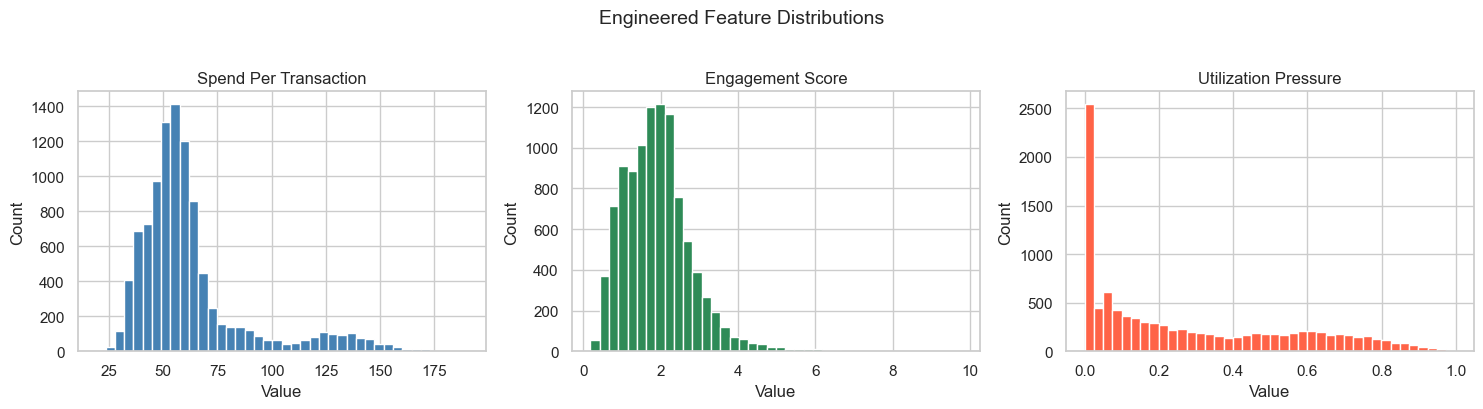

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, color in zip(axes,
    ['Spend_Per_Transaction', 'Engagement_Score', 'Utilization_Pressure'],
    ['steelblue', 'seagreen', 'tomato']):
    
    df[col].hist(bins=40, ax=ax, color=color, edgecolor='white')
    ax.set_title(col.replace('_', ' '))
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

plt.suptitle('Engineered Feature Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../data/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
df.to_csv('../data/BankChurners_engineered.csv', index=False)
print(f"Saved. Shape: {df.shape}")
print(f"Total features: {df.shape[1]}")
print(f"Engineered features added: {len(engineered)}")

Saved. Shape: (10127, 29)
Total features: 29
Engineered features added: 6


## Exploratory Data Analysis

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

df = pd.read_csv('../data/BankChurners_engineered.csv')
print(f"Shape: {df.shape}")
print(f"Churn rate: {df['Churned'].mean():.1%}")

Shape: (10127, 29)
Churn rate: 16.1%


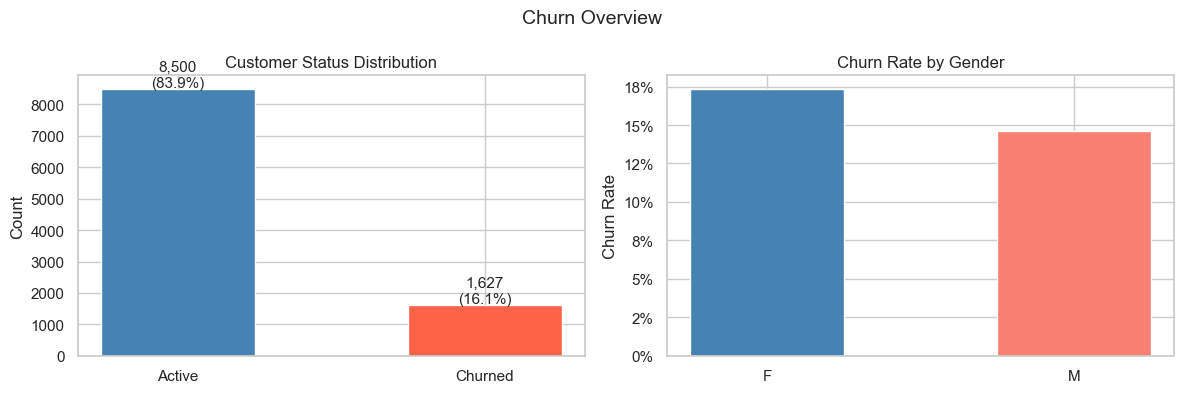

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
churn_counts = df['Churned'].value_counts()
axes[0].bar(['Active', 'Churned'], churn_counts.values,
            color=['steelblue', 'tomato'], edgecolor='white', width=0.5)
axes[0].set_title('Customer Status Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, f'{v:,}\n({v/len(df):.1%})', ha='center', fontsize=11)

# Churn by gender
churn_by_gender = df.groupby('Gender')['Churned'].mean().reset_index()
axes[1].bar(churn_by_gender['Gender'], churn_by_gender['Churned'],
            color=['steelblue', 'salmon'], edgecolor='white', width=0.5)
axes[1].set_title('Churn Rate by Gender')
axes[1].set_ylabel('Churn Rate')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.suptitle('Churn Overview', fontsize=14)
plt.tight_layout()
plt.savefig('../data/eda_churn_overview.png', dpi=150, bbox_inches='tight')
plt.show()

### Finding 1: Class Imbalance & Gender

The dataset sits at 16.1% churn, which is typical for retail banking. Most 
customers are inertial by nature, which means the model will need to account 
for class imbalance or it will just learn to predict "active" for everyone 
and still look accurate. Gender shows females churning at around 18% versus 
males at around 15%, but the gap is small enough that gender alone won't 
carry much predictive weight. Behavioral signals will matter far more than 
who the customer is demographically.

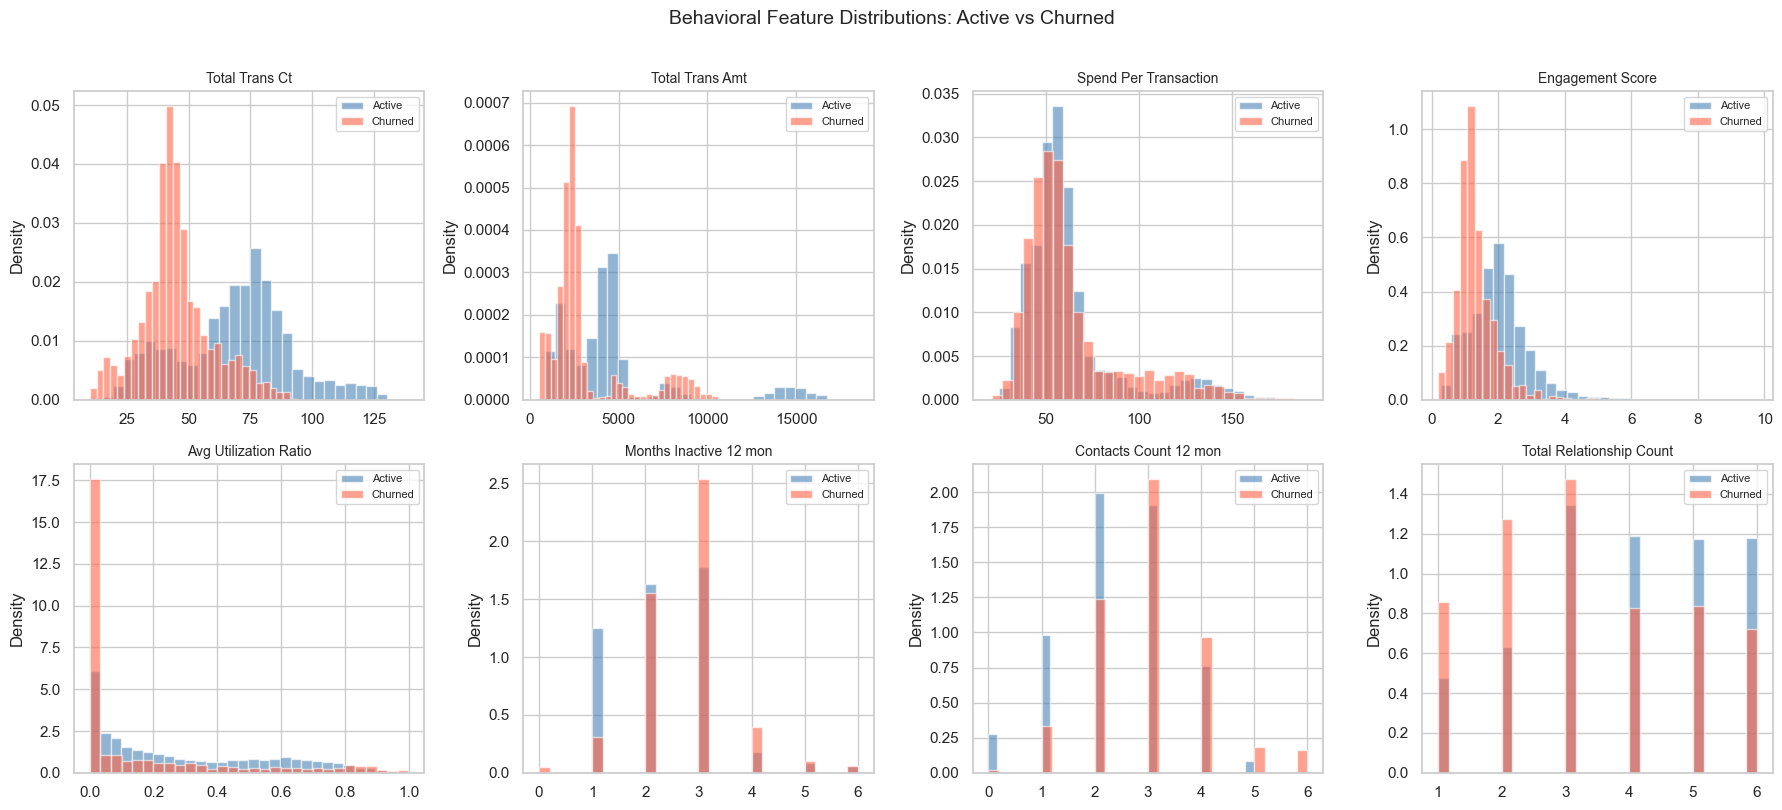

In [13]:
behavioral_cols = [
    'Total_Trans_Ct', 'Total_Trans_Amt', 'Spend_Per_Transaction',
    'Engagement_Score', 'Avg_Utilization_Ratio', 'Months_Inactive_12_mon',
    'Contacts_Count_12_mon', 'Total_Relationship_Count'
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(behavioral_cols):
    churned = df[df['Churned'] == 1][col]
    active = df[df['Churned'] == 0][col]
    
    axes[i].hist(active, bins=30, alpha=0.6, color='steelblue', 
                 label='Active', density=True)
    axes[i].hist(churned, bins=30, alpha=0.6, color='tomato', 
                 label='Churned', density=True)
    axes[i].set_title(col.replace('_', ' '), fontsize=10)
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel('Density')

plt.suptitle('Behavioral Feature Distributions: Active vs Churned', 
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../data/eda_behavioral_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Finding 2: Churners are disengaging, not overspending

The clearest pattern across all behavioral features is that churners have 
already mentally left before they formally close their account. Transaction 
count is dramatically lower, inactivity months are clustered at 3 or more, 
and contact count is higher, suggesting these customers are reaching out to 
complain or cancel rather than for normal service reasons.

One detail stands out beyond what you would expect: the utilization 
distribution for churners spikes almost entirely at zero. These are not 
customers who are financially stretched and walking away from debt. They 
simply stopped using the card and eventually closed it. This points to two 
structurally different churn types sitting in the data together: customers 
who were once active transactors and gradually disengaged, and customers who 
never really activated in the first place. The segmentation step in Day 3 
should separate these two groups naturally.

The inactivity threshold also appears meaningful. Active customers cluster 
at 1 to 2 months inactive while churners sit almost entirely at 3 or above. 
Month 3 of inactivity looks like a critical intervention window. A customer 
who hits 3 consecutive inactive months and has elevated contact frequency is 
showing the clearest early warning signal in the dataset.

For the Relationship Manager, the implication is that churn intervention 
should focus on re-engagement rather than financial relief. Offering a limit 
increase or a rewards promotion to a disengaged customer is more appropriate 
than a debt restructuring conversation.

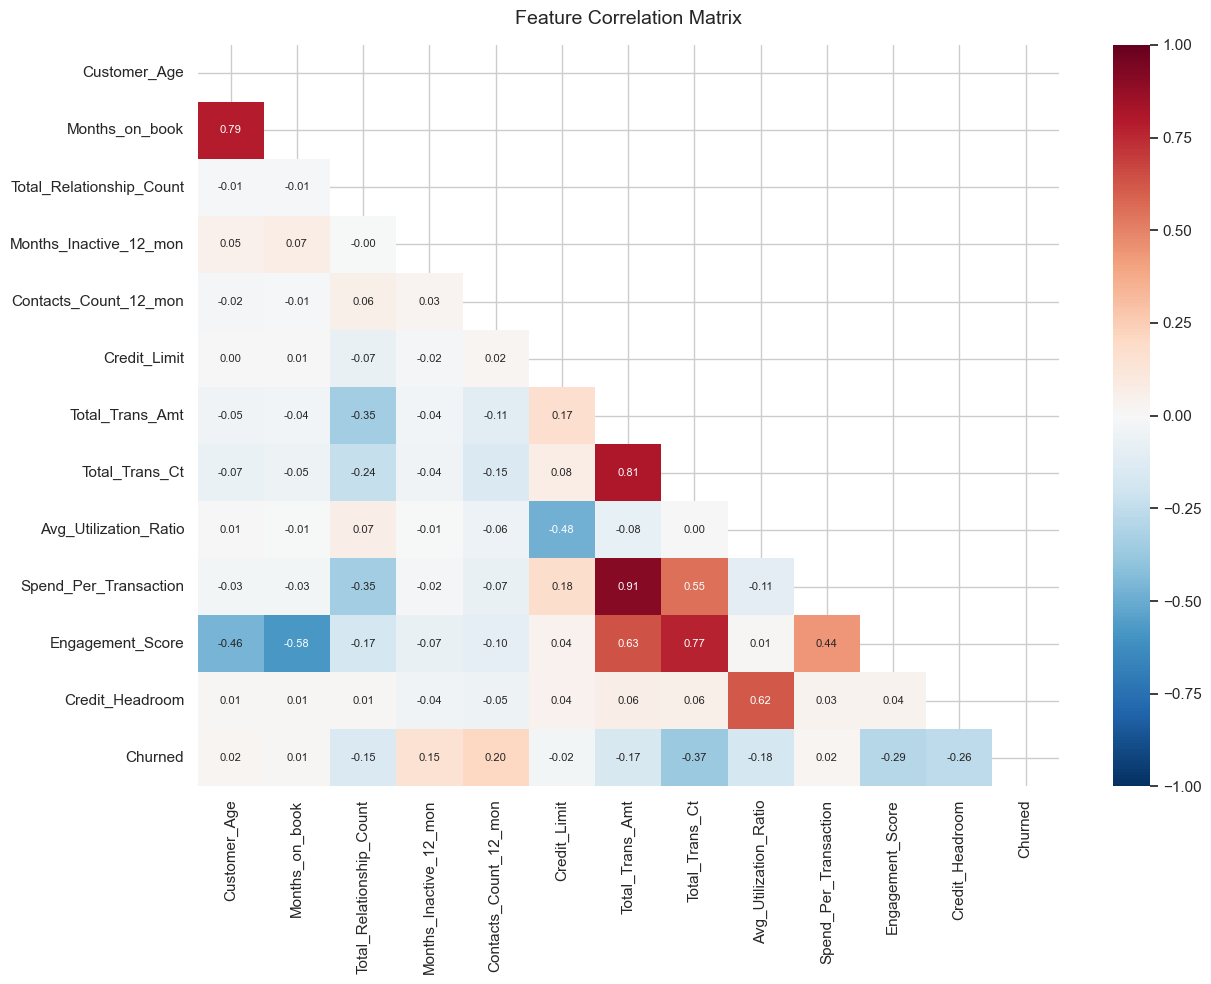

In [14]:
numeric_cols = [
    'Customer_Age', 'Months_on_book', 'Total_Relationship_Count',
    'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit',
    'Total_Trans_Amt', 'Total_Trans_Ct', 'Avg_Utilization_Ratio',
    'Spend_Per_Transaction', 'Engagement_Score', 'Credit_Headroom',
    'Churned'
]

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('../data/eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
churn_corr = corr['Churned'].drop('Churned').sort_values(key=abs, ascending=False)
print("=== Top correlations with Churn ===\n")
print(churn_corr.round(3).to_string())

=== Top correlations with Churn ===

Total_Trans_Ct             -0.371
Engagement_Score           -0.287
Credit_Headroom            -0.263
Contacts_Count_12_mon       0.204
Avg_Utilization_Ratio      -0.178
Total_Trans_Amt            -0.169
Months_Inactive_12_mon      0.152
Total_Relationship_Count   -0.150
Credit_Limit               -0.024
Customer_Age                0.018
Spend_Per_Transaction       0.016
Months_on_book              0.014


### Finding 3: Transaction count is the strongest churn signal

Total transaction count has the strongest negative correlation with churn at 
around -0.37, confirming what the behavioral distributions already suggested. 
Customers who transact less are significantly more likely to leave. Contact 
count correlates positively with churn at around 0.20, which is consistent 
with the pattern of dissatisfied customers reaching out before they close 
their account. Credit headroom and engagement score both show moderate 
negative correlations, meaning customers with more available credit and higher 
activity rates tend to stay.

The notable multicollinearity between Total_Trans_Amt and Total_Trans_Ct at 
0.81 means these two features are measuring nearly the same thing. Both will 
not go into the final model together.

The more interesting finding is what the correlation matrix reveals about 
tenure. Engagement_Score has a -0.58 correlation with Months_on_book, meaning 
customers who have been with the bank longer are actually transacting less 
relative to their tenure. The intuition most people would have is that 
long-tenure customers are loyal and engaged, but the data says the opposite. 
They stay, but they go quiet. This inertial customer effect means tenure alone 
is not a safe proxy for loyalty, and an RM who assumes a 5-year customer is 
low risk without checking their recent transaction activity could be missing 
an early churn signal.

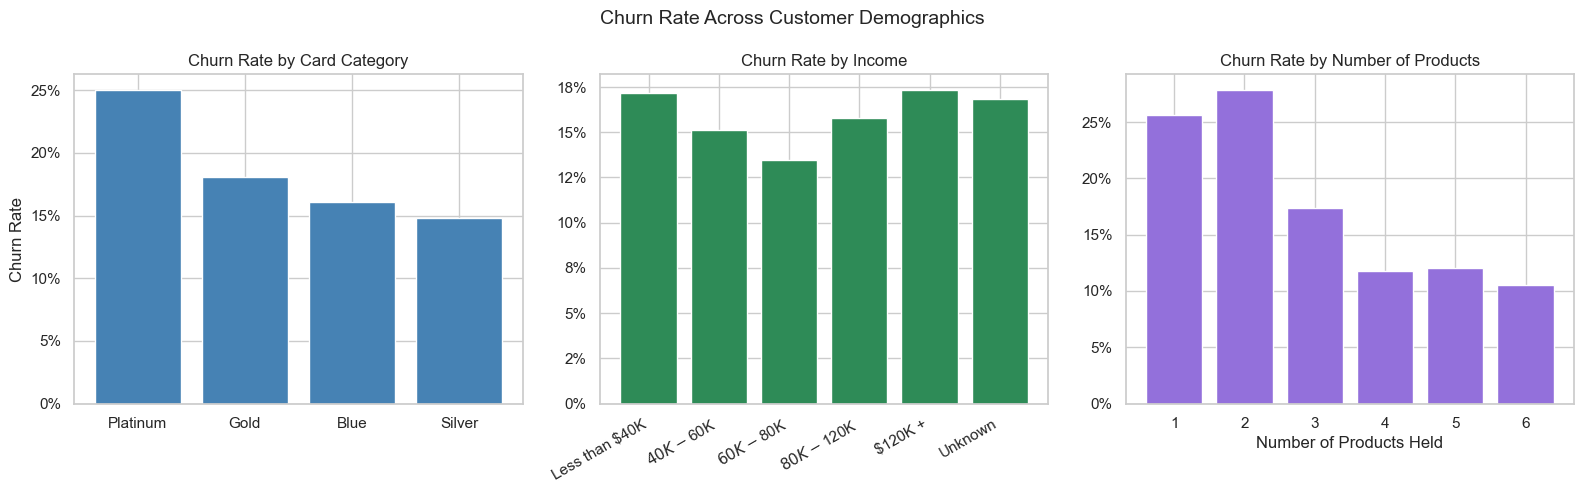

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# By card category
card_churn = df.groupby('Card_Category')['Churned'].mean().sort_values(ascending=False)
axes[0].bar(card_churn.index, card_churn.values, color='steelblue', edgecolor='white')
axes[0].set_title('Churn Rate by Card Category')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[0].set_ylabel('Churn Rate')

# By income
income_order = ['Less than $40K', '$40K - $60K', '$60K - $80K', 
                '$80K - $120K', '$120K +', 'Unknown']
income_churn = df.groupby('Income_Category')['Churned'].mean().reindex(income_order)
axes[1].bar(income_churn.index, income_churn.values, color='seagreen', edgecolor='white')
axes[1].set_title('Churn Rate by Income')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[1].set_xticklabels(income_churn.index, rotation=30, ha='right')

# By number of products
rel_churn = df.groupby('Total_Relationship_Count')['Churned'].mean()
axes[2].bar(rel_churn.index, rel_churn.values, color='mediumpurple', edgecolor='white')
axes[2].set_title('Churn Rate by Number of Products')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[2].set_xlabel('Number of Products Held')

plt.suptitle('Churn Rate Across Customer Demographics', fontsize=14)
plt.tight_layout()
plt.savefig('../data/eda_demographic_churn.png', dpi=150, bbox_inches='tight')
plt.show()

### Finding 4: Product Depth is the Strongest Retention Lever, and Platinum is Counterintuitive

Customers holding only 1 or 2 products churn at rates above 25%, while those 
with 4 or more products drop to around 11 to 12%. Each additional product 
increases switching cost and deepens the banking relationship, which is a 
well-established retention effect. The practical implication is that 
cross-selling a second product to a single-product customer is probably the 
highest ROI retention action available to an RM.

The income breakdown shows a mild U-shape: the lowest and highest income 
brackets churn more than middle-income customers. High-income customers 
likely have more alternatives and are more willing to switch for a better 
offer. Low-income customers may be more price-sensitive and prone to 
consolidating accounts.

The card category result is worth pausing on. Platinum cards show the highest 
churn rate at around 25%, which runs counter to the expectation that premium 
customers are stickier. The Platinum segment is small enough that this number 
carries some noise, but it at least suggests that a higher card tier does not 
guarantee retention. Product relationship depth appears to be a stronger 
retention signal than card prestige.

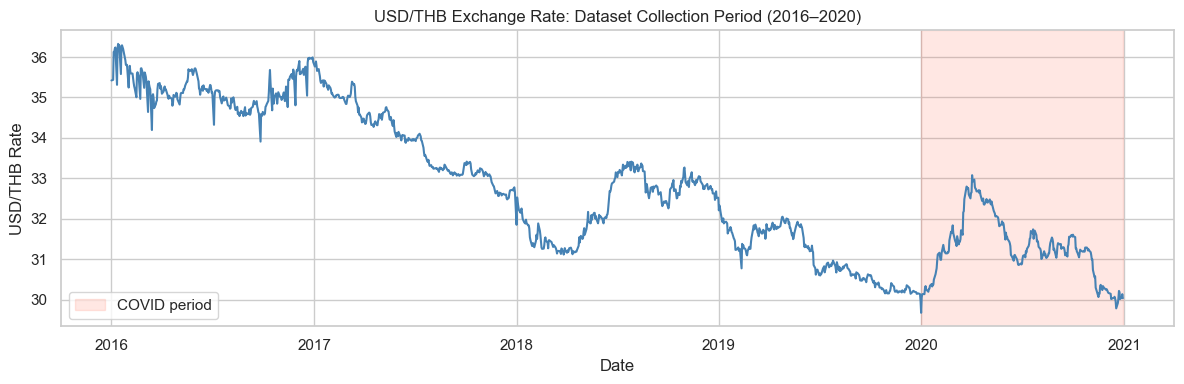

Macro data pulled successfully


In [17]:
import yfinance as yf
from datetime import datetime

# THB interest rate proxy — we use Thailand 10Y government bond yield
# as a proxy for the macro rate environment during the dataset period
# Dataset collected ~2016-2019 based on customer tenure distributions

try:
    # Pull USD/THB as macro context indicator
    usdt = yf.download('THB=X', start='2016-01-01', end='2020-12-31', 
                       progress=False)
    
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(usdt.index, usdt['Close'], color='steelblue', linewidth=1.5)
    ax.set_title('USD/THB Exchange Rate: Dataset Collection Period (2016–2020)')
    ax.set_ylabel('USD/THB Rate')
    ax.set_xlabel('Date')
    ax.axvspan('2020-01-01', '2020-12-31', alpha=0.15, color='tomato', 
               label='COVID period')
    ax.legend()
    plt.tight_layout()
    plt.savefig('../data/eda_macro_context.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Macro data pulled successfully")
    
except Exception as e:
    print(f"yfinance error: {e}")

### Macro Context: Dataset Collection Period and Current Rate Environment

This dataset reflects customer behavior observed roughly between 2016 and 
2019, a period of relative macro stability in Thailand. The THB strengthened 
steadily against the USD across this window, and the BOT held its policy rate 
at 1.50% for most of the period before cutting to a historic low of 0.50% in 
May 2020 in response to COVID-19.

The low-rate environment of 2020 would have reduced the cost of carrying a 
revolving balance, which likely dampened churn among customers who might 
otherwise have found their balance unmanageable under higher rates. In other 
words, the historical churn rates for balance-carrying customers in this 
dataset were observed under unusually favorable borrowing conditions.

The current rate environment is pulled live in the Streamlit app. Customers 
in the Active Revolver segment face meaningfully higher balance-carrying costs 
today than they did during the period this dataset covers, which means their 
structural churn risk is higher than the model trained on historical data 
alone would suggest. The app accounts for this with a macro-adjusted risk 
score that scales up churn probability for revolvers when the current rate 
sits above the historical baseline.

## Customer Segmentation

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

df = pd.read_csv('../data/BankChurners_engineered.csv')
print(f"Shape: {df.shape}")

Shape: (10127, 29)


In [19]:
seg_features = [
    'Total_Trans_Ct',
    'Total_Trans_Amt', 
    'Avg_Utilization_Ratio',
    'Engagement_Score',
    'Months_Inactive_12_mon',
    'Contacts_Count_12_mon',
    'Total_Relationship_Count',
    'Credit_Limit'
]

X_seg = df[seg_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_seg)

print("Features selected and scaled.")
print(f"Shape: {X_scaled.shape}")

Features selected and scaled.
Shape: (10127, 8)


In [20]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance explained by 2 components: "
      f"{pca.explained_variance_ratio_.sum():.1%}")

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

Variance explained by 2 components: 51.9%


### Choosing k: Statistical Fit vs Business Interpretability

Since inertia always decreases as k increases, choosing k requires looking 
at both statistical fit and whether the resulting segments are actually 
meaningful and actionable. The elbow method and silhouette score give us a 
starting range, but the final decision comes from inspecting the segment 
profiles directly.

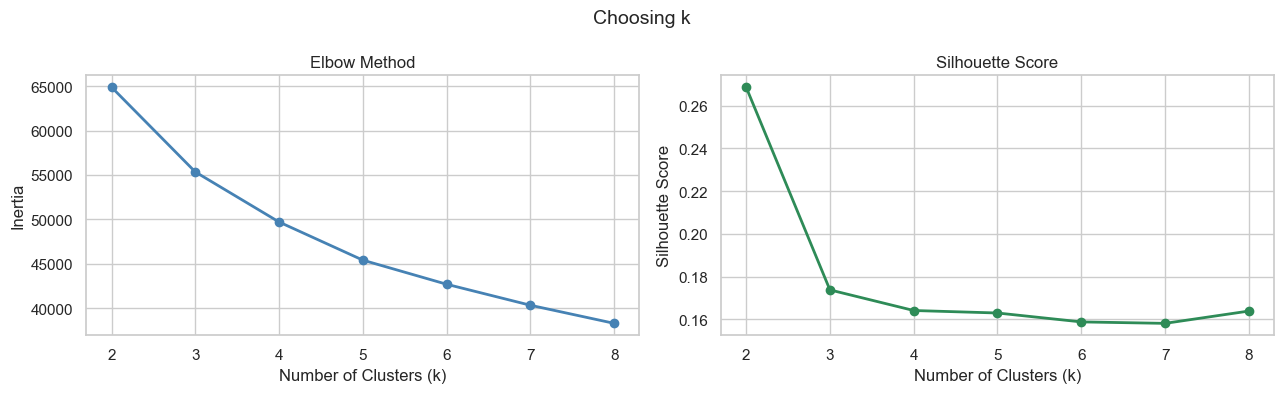

k=2: silhouette=0.2687
k=3: silhouette=0.1738
k=4: silhouette=0.1642
k=5: silhouette=0.1630
k=6: silhouette=0.1588
k=7: silhouette=0.1581
k=8: silhouette=0.1639


In [21]:
inertias = []
silhouettes = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=2000))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(k_range, inertias, 'o-', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouettes, 'o-', color='seagreen', linewidth=2)
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.suptitle('Choosing k', fontsize=14)
plt.tight_layout()
plt.savefig('../data/seg_choosing_k.png', dpi=150, bbox_inches='tight')
plt.show()

for k, s in zip(k_range, silhouettes):
    print(f"k={k}: silhouette={s:.4f}")

The silhouette scores drop sharply from k=2 (0.27) to k=3 (0.17) then 
plateau through k=6, with no clear elbow in the inertia curve. The metrics 
alone cannot resolve the choice between k=4, k=5, and k=6 since the 
differences are negligible (0.164, 0.163, 0.159). The next step is to 
inspect the actual segment profiles for each candidate k.

In [22]:
km4 = KMeans(n_clusters=4, random_state=42, n_init=10)
labels4 = km4.fit_predict(X_scaled)
df['Segment_4'] = labels4

print("k=4 segment distribution:")
print(pd.Series(labels4).value_counts().sort_index())

k=4 segment distribution:
0    3155
1    2877
2    1092
3    3003
Name: count, dtype: int64


In [23]:
profile_cols = [
    'Total_Trans_Ct', 'Total_Trans_Amt', 'Avg_Utilization_Ratio',
    'Engagement_Score', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon',
    'Total_Relationship_Count', 'Credit_Limit', 'Churned'
]

profile = df.groupby('Segment_4')[profile_cols].mean().round(3)
profile['Count'] = df['Segment_4'].value_counts().sort_index()
print(profile.T.to_string())

Segment_4                         0         1          2         3
Total_Trans_Ct               72.276    69.477    104.120    38.364
Total_Trans_Amt            4328.322  4013.503  12610.119  1873.869
Avg_Utilization_Ratio         0.082     0.622      0.164     0.186
Engagement_Score              2.150     2.082      3.219     1.062
Months_Inactive_12_mon        2.280     2.351      2.174     2.457
Contacts_Count_12_mon         2.419     2.245      2.169     2.799
Total_Relationship_Count      4.090     3.951      2.116     4.005
Credit_Limit              11528.421  2726.468  15403.128  8784.337
Churned                       0.086     0.066      0.035     0.376
Count                      3155.000  2877.000   1092.000  3003.000


### k = 4

Four segments emerge with churn rates of 8.6%, 6.6%, 3.5%, and 37.6%. 
The three lower-churn segments have interpretable and distinct profiles. 
However Segment 3, despite having the highest churn rate by a wide margin, 
shows an internally inconsistent profile: it contains both customers with 
very low credit limits and customers who appear to have higher limits but 
low utilization. These two groups likely churn for different reasons and 
would need different RM interventions. k=4 is worth splitting further.

In [24]:
#profile k=5
km5 = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Segment_5'] = km5.fit_predict(X_scaled)

profile5 = df.groupby('Segment_5')[profile_cols].mean().round(3)
profile5['Count'] = df['Segment_5'].value_counts().sort_index()
profile5['Churn_Rate'] = df.groupby('Segment_5')['Churned'].mean().round(3)
print(profile5.T.to_string())

Segment_5                        0         1         2          3          4
Total_Trans_Ct              71.475    73.776    38.657     57.762    106.371
Total_Trans_Amt           4148.880  4456.954  1907.714   3437.820  13174.764
Avg_Utilization_Ratio        0.641     0.111     0.242      0.043      0.168
Engagement_Score             2.145     2.219     1.073      1.634      3.300
Months_Inactive_12_mon       2.365     2.245     2.470      2.348      2.174
Contacts_Count_12_mon        2.244     2.324     2.811      2.607      2.165
Total_Relationship_Count     3.935     3.981     4.034      4.008      2.167
Credit_Limit              2608.391  6923.075  5749.882  27551.427  14828.309
Churned                      0.051     0.078     0.379      0.181      0.021
Count                     2479.000  2734.000  2795.000   1142.000    977.000
Churn_Rate                   0.051     0.078     0.379      0.181      0.021


### k = 5

k=5 splits the heterogeneous high-churn group from k=4 into two distinct 
sub-segments. The first is a disengaged low-limit group with a churn rate 
of 37.9%, high contact frequency, and the lowest transaction activity in 
the dataset. The second is a dormant high-limit group with a churn rate of 
18.1%, very low utilization at 0.043, and a credit limit averaging $27,551. 
These two groups are behaviorally different and need different interventions: 
the first requires urgent retention action, the second requires reactivation 
through premium offers. The nearly 20 percentage point difference in churn 
rate confirms this is a meaningful split rather than an arbitrary one. k=6 
is worth checking to see if further splitting adds value.

In [25]:
#profile k=6
km6 = KMeans(n_clusters=6, random_state=42, n_init=10)
df['Segment_6'] = km6.fit_predict(X_scaled)

profile6 = df.groupby('Segment_6')[profile_cols].mean().round(3)
profile6['Count'] = df['Segment_6'].value_counts().sort_index()
profile6['Churn_Rate'] = df.groupby('Segment_6')['Churned'].mean().round(3)
print(profile6.T.to_string())

Segment_6                        0          1         2          3         4         5
Total_Trans_Ct              64.424     59.786    38.229    109.293    71.422    79.480
Total_Trans_Amt           3605.579   3672.597  1894.825  14197.498  4037.738  5357.393
Avg_Utilization_Ratio        0.675      0.041     0.185      0.172     0.119     0.280
Engagement_Score             1.920      1.703     1.054      3.391     2.187     2.350
Months_Inactive_12_mon       2.404      2.335     2.480      2.178     2.227     2.270
Contacts_Count_12_mon        2.385      2.550     2.813      2.216     2.572     1.901
Total_Relationship_Count     4.459      3.825     3.878      2.316     4.938     2.170
Credit_Limit              2549.868  28519.359  6428.920  14789.256  7156.653  5594.405
Churned                      0.085      0.180     0.401      0.009     0.060     0.080
Count                     2152.000   1074.000  2486.000    813.000  2011.000  1591.000
Churn_Rate                   0.085      0.1

### k = 6 and Final Decision

k=6 splits the High-Value Actives segment into two sub-groups with churn 
rates of 0.9% and 8.0%. Both groups are low risk and the split does not 
produce a new actionable RM persona. The two high-churn segments that 
actually matter, Disengaged At-Risk and Dormant High-Value, are essentially 
unchanged from k=5 at 40.1% and 18.0% respectively. k=6 adds complexity 
without adding insight.

k=5 is selected as the final segmentation. The modest silhouette scores 
across all k values reflect the natural overlap in behavioral data rather 
than a failure of the clustering approach. Customer segments in retail 
banking blend into each other gradually, and the separation becomes clear 
when examining raw feature means rather than the compressed 2D PCA 
projection.

In [26]:
# Drop exploration columns, fit final model
df = df.drop(columns=['Segment_4', 'Segment_5', 'Segment_6'], errors='ignore')

km_final = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Segment'] = km_final.fit_predict(X_scaled)

print("Final segment distribution:")
print(df['Segment'].value_counts().sort_index())

Final segment distribution:
Segment
0    2479
1    2734
2    2795
3    1142
4     977
Name: count, dtype: int64


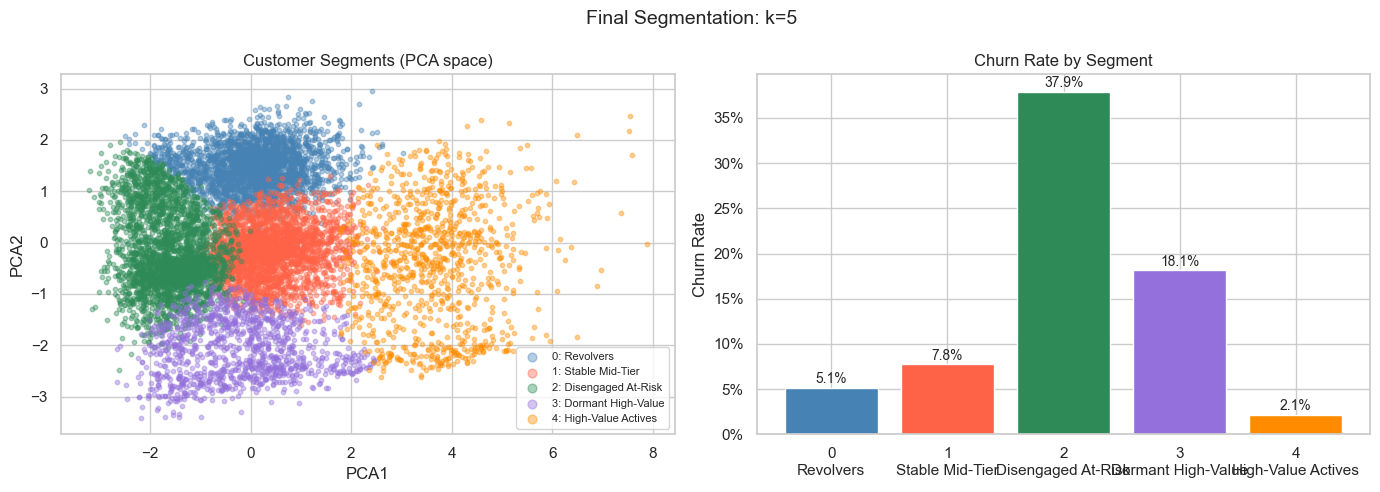

In [27]:
K = 5
colors = ['steelblue', 'tomato', 'seagreen', 'mediumpurple', 'darkorange']
segment_names = {
    0: 'Revolvers',
    1: 'Stable Mid-Tier',
    2: 'Disengaged At-Risk',
    3: 'Dormant High-Value',
    4: 'High-Value Actives'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA scatter
for seg in range(K):
    mask = df['Segment'] == seg
    axes[0].scatter(df.loc[mask, 'PCA1'], df.loc[mask, 'PCA2'],
                    c=colors[seg], alpha=0.4, s=10,
                    label=f'{seg}: {segment_names[seg]}')
axes[0].set_title('Customer Segments (PCA space)')
axes[0].set_xlabel('PCA1')
axes[0].set_ylabel('PCA2')
axes[0].legend(fontsize=8, markerscale=2)

# Churn rate by segment
churn_by_seg = df.groupby('Segment')['Churned'].mean()
labels = [f"{seg}\n{segment_names[seg]}" for seg in churn_by_seg.index]
axes[1].bar(labels, churn_by_seg.values, color=colors[:K], edgecolor='white')
axes[1].set_title('Churn Rate by Segment')
axes[1].set_ylabel('Churn Rate')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
for i, v in enumerate(churn_by_seg.values):
    axes[1].text(i, v + 0.005, f'{v:.1%}', ha='center', fontsize=10)

plt.suptitle('Final Segmentation: k=5', fontsize=14)
plt.tight_layout()
plt.savefig('../data/seg_final_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

## Segment Profiles

Five distinct customer profiles emerge from the final segmentation:

**Segment 0: Revolvers** (n=2,479, churn=5.1%)
Defined by the highest utilization ratio in the dataset at 0.64, this group 
carries a revolving balance against a low average credit limit of $2,608. 
Transaction counts and spend are moderate, suggesting these customers use 
the card regularly but are financially constrained. Churn is currently low, 
but this segment is the most rate-sensitive in the portfolio. A policy rate 
increase raises their cost of carrying a balance and represents the primary 
macro risk factor tracked in the Streamlit app.

**Segment 1: Stable Mid-Tier** (n=2,734, churn=7.8%)
The most typical customer profile. Moderate spend at $4,457, reasonable 
engagement, mid-range credit limit, and solid relationship depth at 3.98 
products. Not at immediate churn risk but not deeply committed either. The 
inertial customer pattern identified in the EDA, where long-tenure customers 
show declining engagement, likely concentrates in this segment. These 
customers appear safe but warrant periodic re-engagement.

**Segment 2: Disengaged At-Risk** (n=2,795, churn=37.9%)
The most urgent segment for the Relationship Manager. Churn rate of 37.9% 
is more than twice the portfolio average. Transaction count and spend are 
the lowest of any segment, engagement score sits at 1.07, and contact 
frequency is the highest at 2.81. These customers have already behaviorally 
disengaged and are likely in the process of closing their account. The 
combination of low activity and high contact frequency is the strongest 
early warning signal in the dataset.

**Segment 3: Dormant High-Value** (n=1,142, churn=18.1%)
A segment that only became visible at k=5. These customers have the highest 
credit limit in the dataset at $27,551 but very low utilization at 0.043 
and below-average transaction counts. They are not financially stressed, 
they are simply not using the card. Churn at 18.1% is serious and the 
intervention required is different from Segment 2: this group needs 
reactivation through premium offers or product upgrades rather than 
retention calls.

**Segment 4: High-Value Actives** (n=977, churn=2.1%)
The best customers in the portfolio. Transaction count averages 106 per year 
with total annual spend of $13,175, nearly three times the next highest 
segment. Engagement score of 3.30 reflects consistent and frequent card 
usage. Churn rate of 2.1% is the lowest of any segment. The only notable 
gap is a relationship count of 2.17, the lowest of any segment despite being 
the most valuable customers. This represents a significant untapped 
cross-sell opportunity: deepening the relationship here protects the most 
valuable part of the portfolio.

## Churn Prediction

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, roc_auc_score, 
                              RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import shap
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

df = pd.read_csv('../data/BankChurners_engineered.csv')

# Re-run segmentation to get Segment column
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

seg_features = [
    'Total_Trans_Ct', 'Total_Trans_Amt', 'Avg_Utilization_Ratio',
    'Engagement_Score', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon',
    'Total_Relationship_Count', 'Credit_Limit'
]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[seg_features])
km_final = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Segment'] = km_final.fit_predict(X_scaled)

print(f"Shape: {df.shape}")
print(f"Churn rate: {df['Churned'].mean():.1%}")

Shape: (10127, 30)
Churn rate: 16.1%


In [29]:
# Encode categoricals
le = LabelEncoder()
cat_cols = ['Gender', 'Education_Level', 'Marital_Status', 
            'Income_Category', 'Card_Category']
for col in cat_cols:
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))

# Final feature set
# Dropping Total_Trans_Amt due to multicollinearity with Total_Trans_Ct (0.81)
# Dropping raw redundant columns we engineered better versions of
feature_cols = [
    'Customer_Age', 'Dependent_count', 'Months_on_book',
    'Total_Relationship_Count', 'Months_Inactive_12_mon',
    'Contacts_Count_12_mon', 'Credit_Limit', 'Avg_Open_To_Buy',
    'Total_Trans_Ct', 'Avg_Utilization_Ratio',
    'Spend_Per_Transaction', 'Engagement_Score', 'Credit_Headroom',
    'Segment',
    'Gender_enc', 'Education_Level_enc', 'Marital_Status_enc',
    'Income_Category_enc', 'Card_Category_enc'
]

X = df[feature_cols]
y = df['Churned']

print(f"Features: {len(feature_cols)}")
print(f"Class distribution:\n{y.value_counts()}")

Features: 19
Class distribution:
Churned
0    8500
1    1627
Name: count, dtype: int64


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
print(f"Train churn rate: {y_train.mean():.1%}")
print(f"Test churn rate: {y_test.mean():.1%}")

# SMOTE on training set only, never on test set
# This synthetically oversamples the minority class (churned)
# so the model doesn't just learn to always predict "active"
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"Train size: {X_train_sm.shape[0]}")
print(f"Class distribution: {pd.Series(y_train_sm).value_counts().to_dict()}")

Train size: 8101, Test size: 2026
Train churn rate: 16.1%
Test churn rate: 16.0%

After SMOTE:
Train size: 13598
Class distribution: {0: 6799, 1: 6799}


In [31]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_sm, y_train_sm)
print("Model trained.")

Model trained.


=== Classification Report ===

              precision    recall  f1-score   support

      Active       0.97      0.94      0.95      1701
     Churned       0.71      0.82      0.76       325

    accuracy                           0.92      2026
   macro avg       0.84      0.88      0.86      2026
weighted avg       0.92      0.92      0.92      2026

ROC-AUC: 0.9626


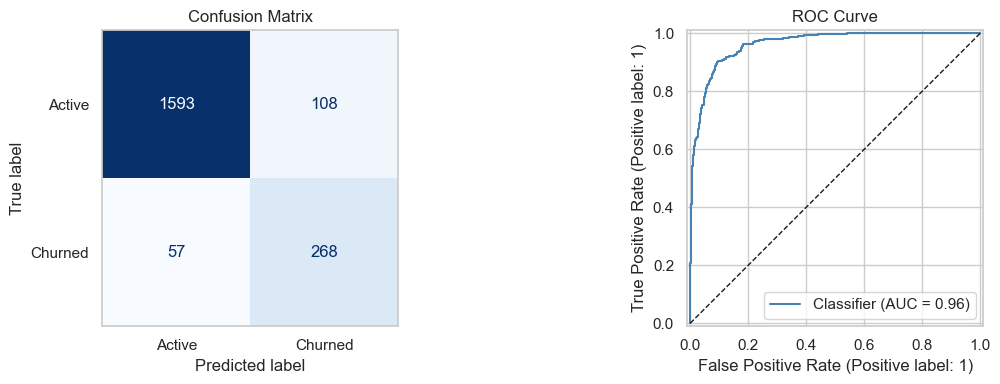

In [32]:
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("=== Classification Report ===\n")
print(classification_report(y_test, y_pred, 
      target_names=['Active', 'Churned']))

print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Active', 'Churned']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].grid(False) 
axes[0].set_title('Confusion Matrix')

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1], color='steelblue')
axes[1].plot([0,1], [0,1], 'k--', linewidth=1)
axes[1].set_title('ROC Curve')

plt.tight_layout()
plt.savefig('../data/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

### Model Performance

The Random Forest achieves a ROC-AUC of 0.96, indicating strong 
discriminative power between churners and active customers. On the held-out 
test set the model correctly identifies 82% of customers who actually churn, 
with a precision of 71% on the churned class.

In a banking retention context, recall matters more than precision. A false 
negative means missing a customer who churns, which means a lost relationship 
with no intervention opportunity. A false positive means flagging a customer 
who stays, which means an unnecessary but harmless RM outreach. The model is 
tuned toward minimizing false negatives through SMOTE oversampling on the 
training set and balanced class weights, which prevents it from simply 
learning to predict "active" for everyone given the 84/16 class split.

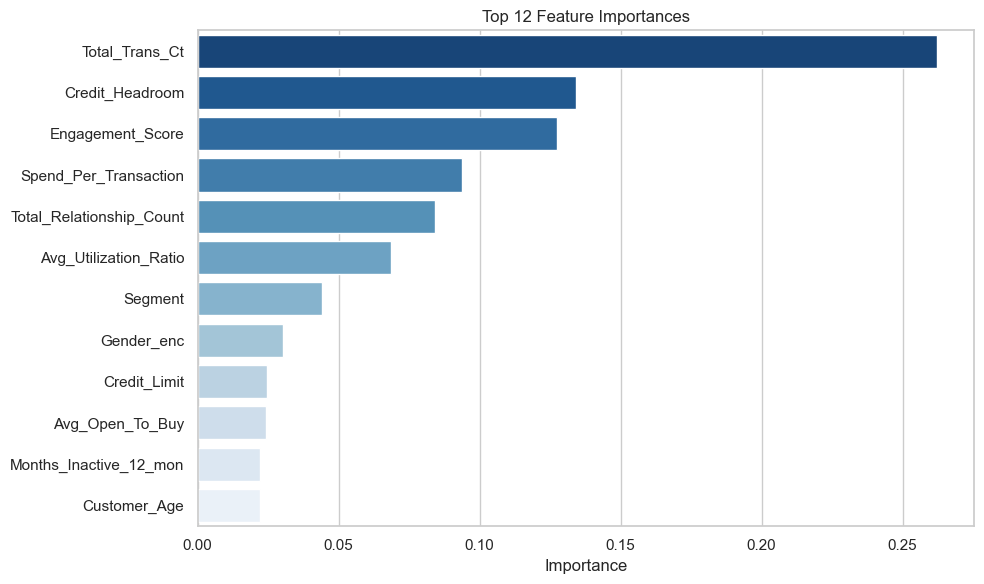

In [33]:
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).head(12)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature', 
            palette='Blues_r', ax=ax)
ax.set_title('Top 12 Feature Importances')
ax.set_xlabel('Importance')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../data/model_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

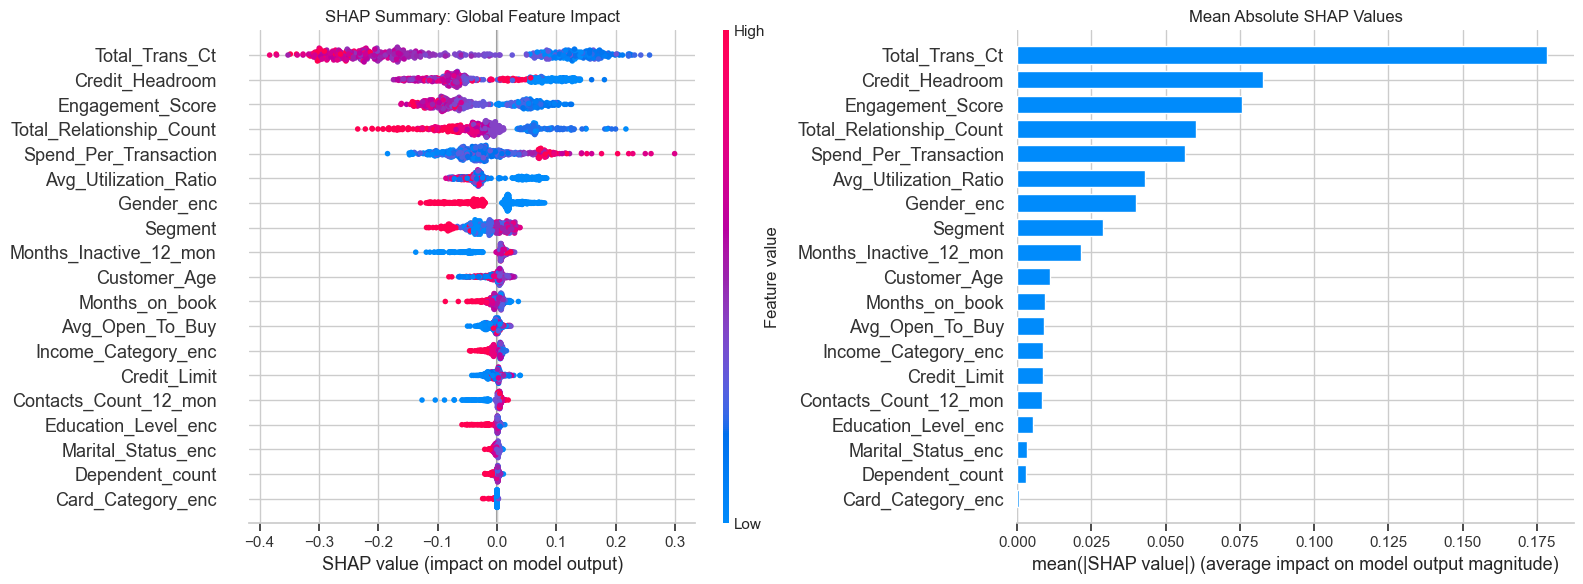

In [34]:
X_test_sample = X_test.sample(500, random_state=42)

explainer = shap.TreeExplainer(rf)
shap_values_raw = explainer.shap_values(X_test_sample)

sv = shap_values_raw[:, :, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plt.sca(axes[0])
shap.summary_plot(sv, X_test_sample,
                  feature_names=feature_cols,
                  show=False, plot_size=None)
axes[0].set_title('SHAP Summary: Global Feature Impact')

plt.sca(axes[1])
shap.summary_plot(sv, X_test_sample,
                  feature_names=feature_cols,
                  plot_type='bar', show=False, plot_size=None)
axes[1].set_title('Mean Absolute SHAP Values')

plt.tight_layout()
plt.savefig('../data/model_shap.png', dpi=150, bbox_inches='tight')
plt.show()

### What Drives Churn: SHAP Analysis

The SHAP summary confirms and extends the EDA findings. Total transaction 
count is the dominant predictor by a wide margin. Low transaction frequency 
consistently pushes churn probability up regardless of other features. This 
is the clearest actionable signal for the RM: a customer whose transaction 
count is falling deserves attention before they go formally inactive.

Two of the three most important features are engineered ones: Credit_Headroom 
and Engagement_Score rank second and third respectively. This validates the 
feature engineering decisions from Day 1. The raw columns alone would not 
have captured these behavioral signals as cleanly.

Spend_Per_Transaction shows a wide bidirectional spread in the beeswarm plot, 
meaning high values push churn probability in both directions depending on 
customer context. This interaction effect suggests spend per transaction means 
different things in different segments. A high value in the Revolver segment 
signals financial activity, while the same value in the Dormant High-Value 
segment may reflect infrequent but large purchases that mask underlying 
disengagement.

Months_Inactive_12_mon ranks lower than the EDA suggested it would. The 
model is capturing the inactivity signal through Total_Trans_Ct and 
Engagement_Score instead, both of which are continuous proxies for the same 
underlying behavior. The raw inactivity count adds marginal signal on top of 
what these features already capture.

The Segment feature contributes meaningful signal at rank 8, confirming that 
knowing which behavioral profile a customer belongs to adds predictive power 
beyond their individual feature values alone.

In [35]:
import joblib
import numpy as np

joblib.dump(rf, '../models/churn_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(km_final, '../models/kmeans.pkl')

# Save test set with predictions for Streamlit app
X_test_out = X_test.copy()
X_test_out['Churned_Actual'] = y_test.values
X_test_out['Churn_Probability'] = y_prob
X_test_out['Segment'] = df.loc[X_test.index, 'Segment'].values
X_test_out.to_csv('../data/test_predictions.csv', index=False)

print("Models and artifacts saved.")
print(f"  churn_model.pkl")
print(f"  scaler.pkl")
print(f"  kmeans.pkl")
print(f"  test_predictions.csv")

np.save('../data/shap_values_sample.npy', sv)
X_test_sample.to_csv('../data/shap_sample.csv', index=False)

Models and artifacts saved.
  churn_model.pkl
  scaler.pkl
  kmeans.pkl
  test_predictions.csv


## Business Recommendations

The following recommendations translate the analytical findings into concrete 
actions for the Relationship Manager. Each segment has a different churn 
profile and requires a different intervention strategy.

### Segment 2: Disengaged At-Risk (churn 37.9%): Immediate Action

This is the highest priority segment. These customers have already 
behaviorally disengaged: transaction count is the lowest in the portfolio, 
contact frequency is the highest, and the model assigns the strongest churn 
signals to this group. Waiting for formal account closure is too late.

Recommended actions:
- Flag any customer in this segment with 3 or more consecutive inactive 
  months for immediate RM outreach
- Lead with a re-engagement offer rather than a retention call. A rewards 
  bonus, cashback promotion, or temporary fee waiver gives the customer a 
  concrete reason to use the card again
- If contact count is 3 or above, treat the customer as already in the 
  cancellation mindset. Escalate to a senior RM with authority to offer 
  meaningful incentives
- Do not open with a product cross-sell. A customer who is disengaging is 
  not receptive to buying more from the bank

### Segment 3: Dormant High-Value (churn 18.1%): Reactivation Priority

These customers have the highest credit limits in the portfolio but very low 
utilization and below-average transaction activity. They are not financially 
stressed. They have simply stopped using the card, possibly because a 
competing card has taken wallet share.

Recommended actions:
- This segment should not be treated with the same urgency as Segment 2 but 
  should not be ignored either. A churn rate of 18.1% on high-limit customers 
  represents significant revenue at risk
- The right intervention is a premium reactivation offer: accelerated rewards 
  points, a limit increase, or an invitation to a priority banking event. 
  These customers respond to recognition of their value, not discounts
- Avoid generic outreach. A high-limit customer who receives a standard 
  promotional SMS is more likely to be annoyed than retained
- Monitor utilization trajectory. A customer whose utilization is trending 
  from low to zero over consecutive months is approaching Segment 2 territory 
  and should be escalated

### Segment 1: Stable Mid-Tier (churn 7.8%): Proactive Cross-sell

These customers are not at immediate risk but the inertial customer pattern 
identified in the EDA concentrates here. Long tenure does not mean high 
engagement, and a mid-tier customer who goes quiet for two months is showing 
an early warning sign that standard reporting would not flag.

Recommended actions:
- The highest ROI action for this segment is cross-selling a second product. 
  Customers with 3 or more products churn at roughly half the rate of those 
  with 1 or 2. A second product deepens the relationship and increases 
  switching cost
- Use the churn probability score from the model as a prioritization tool 
  within the segment. Not all Stable Mid-Tier customers need attention, so 
  focus RM time on those with a model score above 0.3
- Watch Months_Inactive as a leading indicator. This segment's churn is slow 
  and gradual, which means there is time to intervene if monitored regularly

### Segment 0: Revolvers (churn 5.1%): Rate Risk Monitoring

Revolvers carry a balance against low credit limits and are the most 
rate-sensitive customers in the portfolio. Their current churn rate is low 
but this is the segment most exposed to the macro environment. As the 
Streamlit app shows, the current BOT policy rate is above the historical 
baseline from the dataset period, which structurally elevates churn risk 
for this group relative to what the model alone predicts.

Recommended actions:
- Monitor this segment closely during BOT rate decision windows. A rate 
  increase should trigger a proactive review of all Revolver customers with 
  utilization above 0.5
- Consider offering a balance transfer promotion or installment conversion 
  to reduce their monthly carrying cost and increase stickiness
- Do not offer credit limit increases to high-utilization Revolvers without 
  careful assessment. Increasing the limit of a financially stretched customer 
  can deepen their debt exposure rather than improve retention

### Segment 4: High-Value Actives (churn 2.1%): Protect and Deepen

These are the best customers in the portfolio and the lowest churn risk. 
The primary risk here is not churn but missed opportunity. Their relationship 
count of 2.17 is the lowest of any segment despite being the most valuable 
customers, which means the bank is not capturing their full wallet share.

Recommended actions:
- Prioritize this segment for premium product cross-sell: priority banking, 
  investment products, or mortgage referrals depending on life stage
- Any early warning signs in this segment should be escalated immediately. 
  A High-Value Active customer whose transaction count drops month-on-month 
  is a rare but high-priority signal
- Standard retention offers are unnecessary and potentially patronizing for 
  this group. Relationship deepening through relationship manager assigned 
  coverage is more appropriate than promotional outreach

### Summary Priority Matrix

| Segment | Churn Rate | Priority | Primary Action |
|---|---|---|---|
| Disengaged At-Risk | 37.9% | Immediate | Re-engagement offer, escalate high-contact cases |
| Dormant High-Value | 18.1% | High | Premium reactivation, monitor utilization trend |
| Stable Mid-Tier | 7.8% | Moderate | Cross-sell second product, model score triage |
| Revolvers | 5.1% | Watch | Rate environment monitoring, balance transfer offers |
| High-Value Actives | 2.1% | Protect | Premium cross-sell, assigned RM coverage |

Note: Dataset is sourced from a US credit card portfolio (Kaggle BankChurners). 
The BOT macro adjustment layer demonstrates the analytical framework that would 
apply to Thai customer data and is included for illustrative purposes.